In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [12]:
df = pd.read_csv(r"E:\Study Documentation\ML Projects\telco-churn-prediction\data\raw\Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

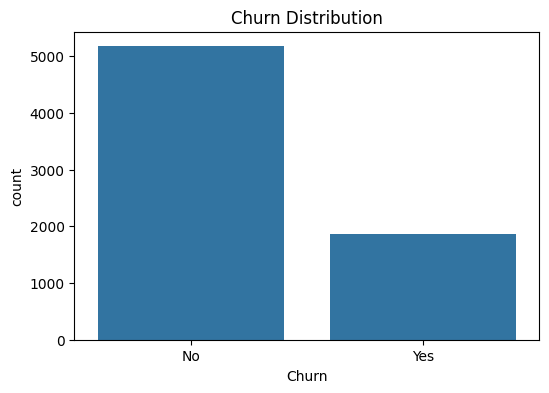

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

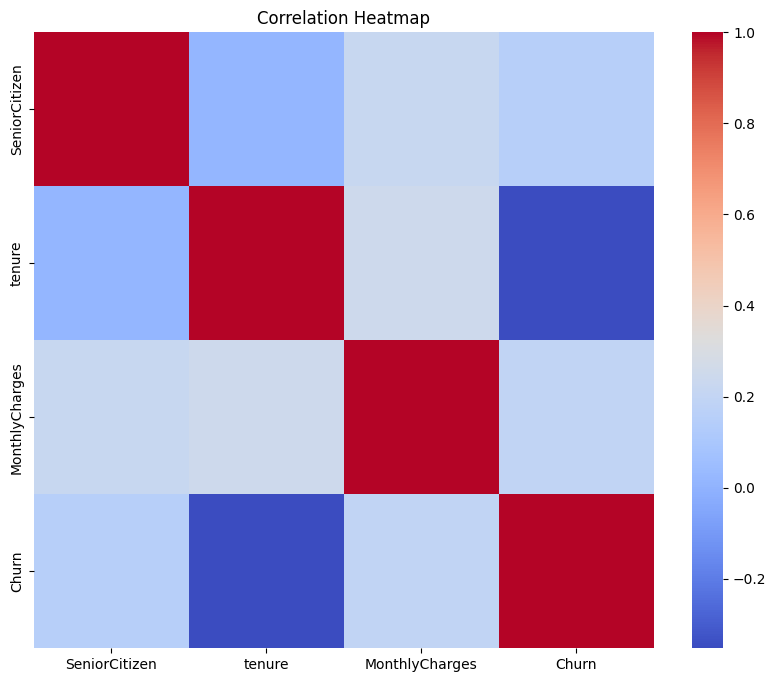

In [16]:
# Convert target to numeric for correlation
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Correlation with target
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
corr_with_target = corr["Churn"].sort_values(ascending=False)
corr_with_target

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64

In [18]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [20]:
df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [22]:
df = df.drop("customerID", axis=1)

In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5634, 19)
Test set: (1409, 19)


In [26]:
# Identify column types again 
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Model with class balancing
model = LogisticRegression(max_iter=1000, class_weight="balanced")

# Full pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model)
])

# Train
clf.fit(X_train, y_train)

C:\Users\Acer\AppData\Local\Temp\ipykernel_19696\224354878.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [27]:
# Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC Score: 0.8416388953473353


In [28]:
from sklearn.ensemble import RandomForestClassifier

# New model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# New pipeline
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

# Train
rf_clf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Random Forest ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Random Forest ROC AUC: 0.823214239582526


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC AUC Scores:", scores)
print("Mean ROC AUC:", scores.mean())

Cross Validation ROC AUC Scores: [0.85826294 0.85847994 0.83313054 0.83778477 0.83926189]
Mean ROC AUC: 0.8453840146655545


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"]
}

grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

Best Parameters: {'classifier__C': 100, 'classifier__penalty': 'l2'}
Best CV ROC AUC: 0.8456045764591467


e:\Study Documentation\ML Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [31]:
best_model = grid_search.best_estimator_

# Predictions
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

print("Final Test Classification Report:\n")
print(classification_report(y_test, y_pred_final))

print("Final Test ROC AUC:", roc_auc_score(y_test, y_prob_final))

Final Test Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Final Test ROC AUC: 0.8402877883696298


In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Calculate imbalance ratio
ratio = (y == 0).sum() / (y == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric="logloss"
)

xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

scores = cross_val_score(
    xgb_clf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("XGBoost CV ROC AUC Scores:", scores)
print("Mean ROC AUC:", scores.mean())

XGBoost CV ROC AUC Scores: [0.85120256 0.85448862 0.82614637 0.83892451 0.84129827]
Mean ROC AUC: 0.8424120656253212


In [33]:
import numpy as np
from sklearn.metrics import f1_score

# Get probabilities from best model
best_model = clf  # your logistic regression pipeline

y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.5500000000000002
Best F1 Score: 0.6175824175824176


In [34]:
best_model = clf

y_prob = best_model.predict_proba(X_test)[:, 1]

best_threshold = 0.55
y_pred_threshold = (y_prob >= best_threshold).astype(int)

print("Classification Report with Optimized Threshold:\n")
print(classification_report(y_test, y_pred_threshold))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Classification Report with Optimized Threshold:

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC AUC: 0.8416388953473353


In [35]:
import joblib

joblib.dump(best_model, "../models/churn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [36]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = best_model.named_steps["classifier"].coef_[0]

# Create dataframe
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute importance
importance_df["AbsValue"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values("AbsValue", ascending=False)

importance_df.head(10)

,Feature,Coefficient,AbsValue
1,num__tenure,-1.154434,1.154434
38,cat__Contract_Two year,-0.775518,0.775518
16,cat__InternetService_Fiber optic,0.707981,0.707981
2,num__MonthlyCharges,-0.676114,0.676114
36,cat__Contract_Month-to-month,0.657713,0.657713
15,cat__InternetService_DSL,-0.622465,0.622465
3,num__TotalCharges,0.489698,0.489698
28,cat__TechSupport_No internet service,-0.275403,0.275403
25,cat__DeviceProtection_No internet service,-0.275403,0.275403
17,cat__InternetService_No,-0.275403,0.275403


In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

# Correct parameter names with prefix
param_dist = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9],
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Best Parameters: {'classifier__subsample': 0.9, 'classifier__n_estimators': 500, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}
Best CV ROC AUC: 0.8494845435850001


In [38]:
best_xgb_model = random_search.best_estimator_

# Predictions
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Use previously found optimal threshold (0.45)
threshold = 0.45
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

print("XGBoost Test Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost Test ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Test Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

XGBoost Test ROC AUC: 0.8474359967966105


In [39]:
import numpy as np
from sklearn.metrics import f1_score

# Use best tuned XGBoost model
best_xgb_model = random_search.best_estimator_

# Get probabilities
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold for XGBoost:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold for XGBoost: 0.3500000000000001
Best F1 Score: 0.6422668240850059


In [40]:
# Use best tuned XGBoost
best_xgb_model = random_search.best_estimator_

# Probabilities
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Apply optimized threshold
best_threshold = 0.35
y_pred_final_xgb = (y_prob_xgb >= best_threshold).astype(int)

print("Final XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_final_xgb))

print("Final XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

Final XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1035
           1       0.58      0.73      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409

Final XGBoost ROC AUC: 0.8474359967966105


In [41]:
import joblib

joblib.dump(best_xgb_model, "../models/churn_xgb_model.pkl")

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [ ]:
import joblib

joblib.dump(best_xgb_model, "../models/churn_xgb_pipeline.pkl")

print("Full pipeline saved successfully.")

In [42]:
X.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [43]:
y.unique()

array([0, 1])